# CropGuard AI — MobileNetV3Large Transfer Learning

This notebook trains the MobileNetV3Large comparison model for CropGuard AI.

Purpose:
- Train a lightweight transfer learning model
- Compare against Custom CNN baseline and EfficientNetV2B0
- Save trained model
- Save training curves
- Save classification report
- Save confusion matrix
- Save wrong prediction summary
- Export outputs back to the PyCharm project

In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

2026-06-23 17:37:21.503206: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1782236241.698349      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1782236241.750587      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1782236242.197899      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782236242.197939      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1782236242.197941      58 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [2]:
from pathlib import Path
import json
import random
import zipfile

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
SEED = 42
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

HEAD_EPOCHS = 5
FINE_TUNE_EPOCHS = 5
TOTAL_EPOCHS = HEAD_EPOCHS + FINE_TUNE_EPOCHS

tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

WORKING_DIR = Path("/kaggle/working")

MODELS_DIR = WORKING_DIR / "models"
OUTPUTS_DIR = WORKING_DIR / "outputs"
METRICS_DIR = OUTPUTS_DIR / "metrics"
LOGS_DIR = OUTPUTS_DIR / "training_logs"
ERROR_DIR = OUTPUTS_DIR / "error_analysis"

for folder in [MODELS_DIR, OUTPUTS_DIR, METRICS_DIR, LOGS_DIR, ERROR_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("Working directory:", WORKING_DIR)

Working directory: /kaggle/working


In [6]:
from tensorflow.keras import mixed_precision

try:
    mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision enabled:", mixed_precision.global_policy())
except Exception as e:
    print("Mixed precision not enabled:", e)

Mixed precision enabled: <DTypePolicy "mixed_float16">


In [7]:
def find_dataset_root():
    input_root = Path("/kaggle/input")

    for train_dir in input_root.rglob("train"):
        valid_dir = train_dir.parent / "valid"

        if valid_dir.exists():
            return train_dir.parent, train_dir, valid_dir

    raise FileNotFoundError(
        "Could not find train/valid folders. "
        "Make sure vipoooool/new-plant-diseases-dataset is added as Kaggle input."
    )


DATASET_ROOT, TRAIN_DIR, VALID_DIR = find_dataset_root()

print("Dataset root:", DATASET_ROOT)
print("Train dir:", TRAIN_DIR)
print("Valid dir:", VALID_DIR)

Dataset root: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)
Train dir: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
Valid dir: /kaggle/input/datasets/vipoooool/new-plant-diseases-dataset/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [8]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

class_names = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
num_classes = len(class_names)

train_counts = {}
valid_counts = {}

for class_name in class_names:
    train_class_dir = TRAIN_DIR / class_name
    valid_class_dir = VALID_DIR / class_name

    train_counts[class_name] = len([
        p for p in train_class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

    valid_counts[class_name] = len([
        p for p in valid_class_dir.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ])

train_total = sum(train_counts.values())
valid_total = sum(valid_counts.values())

print("Number of classes:", num_classes)
print("Total train images:", train_total)
print("Total valid images:", valid_total)

distribution_df = pd.DataFrame([
    {
        "class_name": class_name,
        "train_count": train_counts[class_name],
        "valid_count": valid_counts[class_name],
    }
    for class_name in class_names
])

distribution_path = METRICS_DIR / "mobilenetv3large_dataset_distribution.csv"
distribution_df.to_csv(distribution_path, index=False)

distribution_df.head()

Number of classes: 38
Total train images: 70295
Total valid images: 17572


,class_name,train_count,valid_count
0,Apple___Apple_scab,2016,504
1,Apple___Black_rot,1987,497
2,Apple___Cedar_apple_rust,1760,440
3,Apple___healthy,2008,502
4,Blueberry___healthy,1816,454


In [9]:
class_indices = {str(index): class_name for index, class_name in enumerate(class_names)}

with open(MODELS_DIR / "class_indices.json", "w", encoding="utf-8") as f:
    json.dump(class_indices, f, indent=4)

class_weights = {}

for index, class_name in enumerate(class_names):
    class_count = train_counts[class_name]
    class_weights[index] = train_total / (num_classes * class_count)

with open(MODELS_DIR / "class_weights.json", "w", encoding="utf-8") as f:
    json.dump({str(k): float(v) for k, v in class_weights.items()}, f, indent=4)

print("Saved class_indices.json")
print("Saved class_weights.json")

Saved class_indices.json
Saved class_weights.json


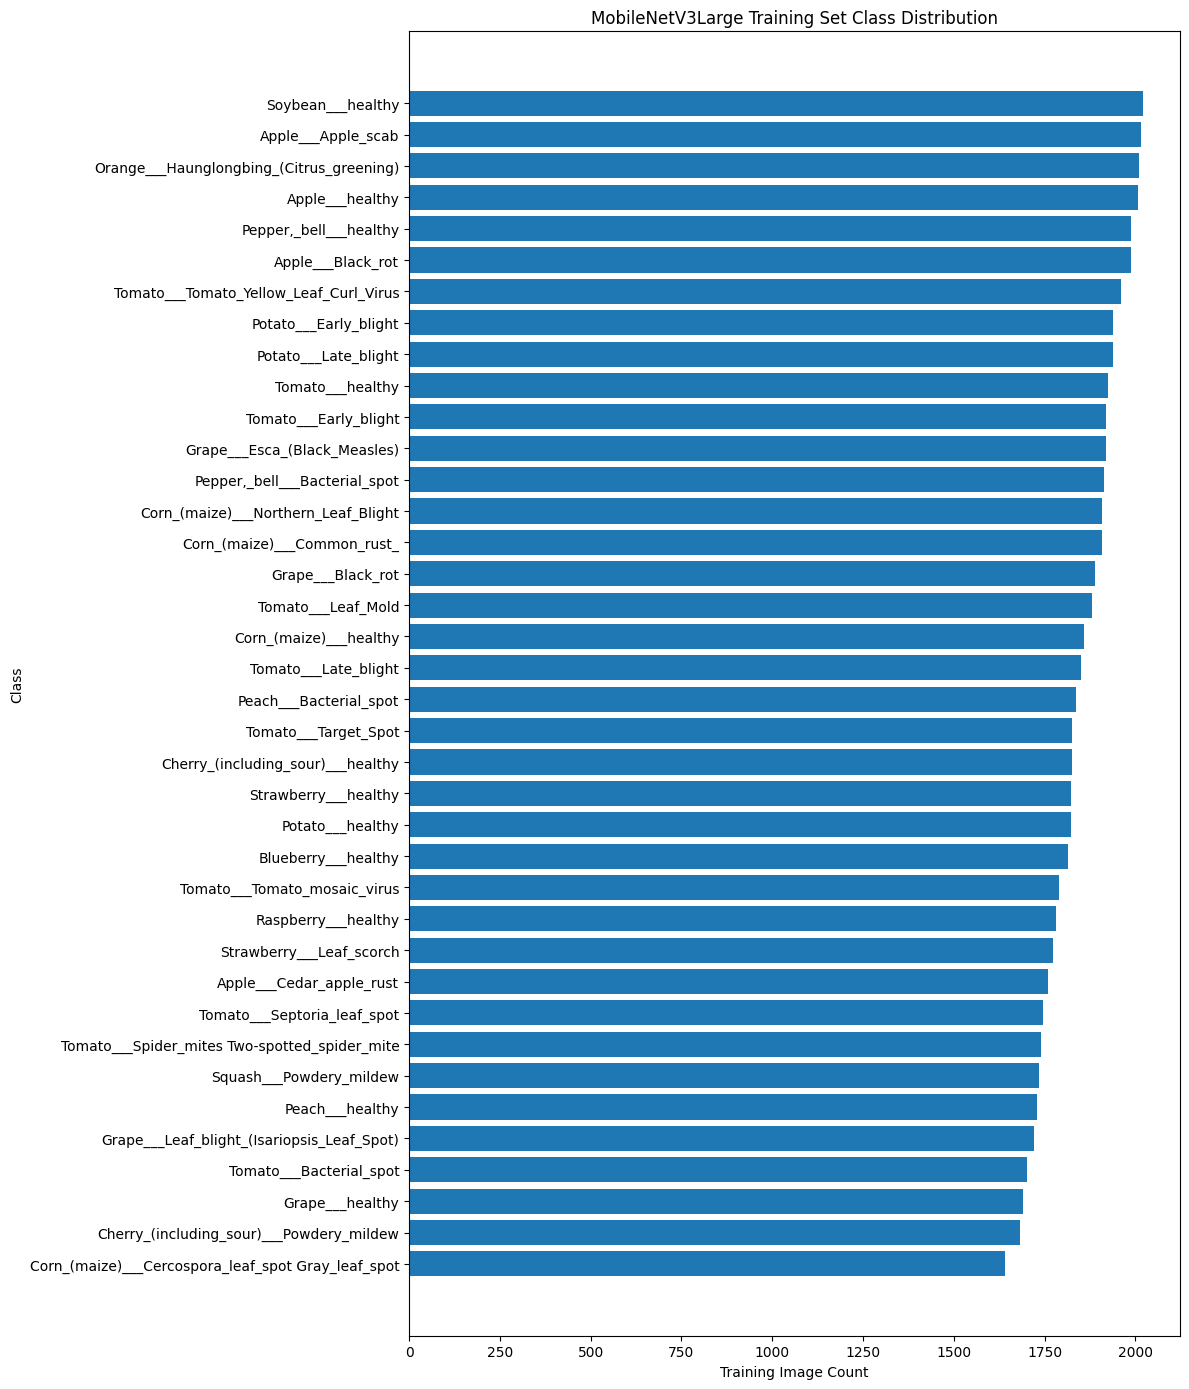

Saved: /kaggle/working/outputs/metrics/mobilenetv3large_class_distribution.png


In [10]:
plt.figure(figsize=(12, 14))

plot_df = distribution_df.sort_values("train_count", ascending=True)

plt.barh(plot_df["class_name"], plot_df["train_count"])
plt.xlabel("Training Image Count")
plt.ylabel("Class")
plt.title("MobileNetV3Large Training Set Class Distribution")
plt.tight_layout()

class_distribution_path = METRICS_DIR / "mobilenetv3large_class_distribution.png"
plt.savefig(class_distribution_path, dpi=200)
plt.show()

print("Saved:", class_distribution_path)

In [11]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED,
)

valid_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    labels="inferred",
    label_mode="int",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    class_names=train_ds.class_names,
)

print("Classes loaded:", len(train_ds.class_names))
print("First 5 classes:", train_ds.class_names[:5])

Found 70295 files belonging to 38 classes.


I0000 00:00:1782236673.213701      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1782236673.219797      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Found 17572 files belonging to 38 classes.
Classes loaded: 38
First 5 classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


In [12]:
for images, labels in train_ds.take(1):
    print("Image batch shape:", images.shape)
    print("Label batch shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Label dtype:", labels.dtype)
    print("Min pixel:", tf.reduce_min(images).numpy())
    print("Max pixel:", tf.reduce_max(images).numpy())

Image batch shape: (32, 224, 224, 3)
Label batch shape: (32,)
Image dtype: <dtype: 'float32'>
Label dtype: <dtype: 'int32'>
Min pixel: 0.0
Max pixel: 255.0


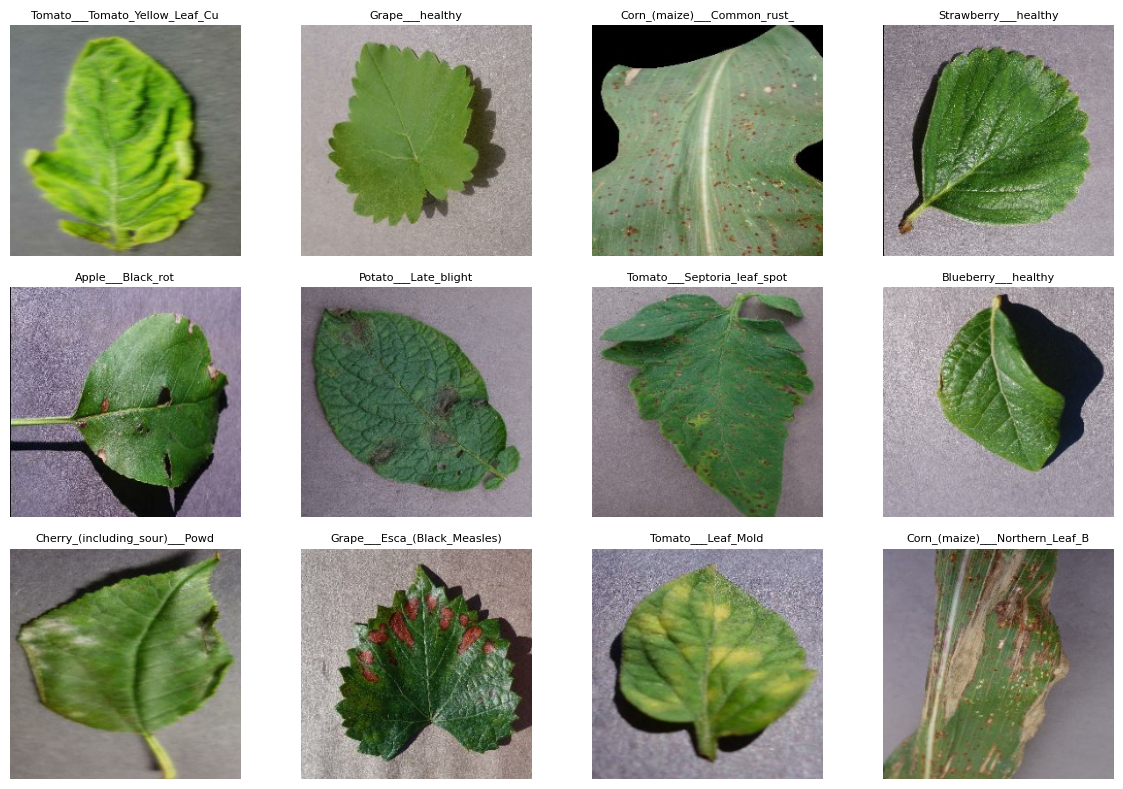

Saved: /kaggle/working/outputs/metrics/mobilenetv3large_sample_images.png


In [13]:
plt.figure(figsize=(12, 8))

for images, labels in train_ds.take(1):
    for i in range(12):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[int(labels[i])][:30], fontsize=8)
        plt.axis("off")

plt.tight_layout()

sample_path = METRICS_DIR / "mobilenetv3large_sample_images.png"
plt.savefig(sample_path, dpi=200)
plt.show()

print("Saved:", sample_path)

In [14]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(AUTOTUNE)
valid_ds = valid_ds.prefetch(AUTOTUNE)

print("Datasets optimized with prefetch.")

Datasets optimized with prefetch.


In [16]:
def build_mobilenetv3large(num_classes):
    data_augmentation = tf.keras.Sequential(
        [
            tf.keras.layers.RandomFlip("horizontal"),
            tf.keras.layers.RandomRotation(0.08),
            tf.keras.layers.RandomZoom(0.10),
            tf.keras.layers.RandomContrast(0.10),
        ],
        name="data_augmentation",
    )

    inputs = tf.keras.Input(shape=(224, 224, 3))

    x = data_augmentation(inputs)

    base_model = tf.keras.applications.MobileNetV3Large(
        input_shape=(224, 224, 3),
        include_top=False,
        weights="imagenet",
        include_preprocessing=True,
    )

    base_model.trainable = False

    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D(name="global_average_pooling")(x)
    x = tf.keras.layers.Dropout(0.35)(x)

    outputs = tf.keras.layers.Dense(
        num_classes,
        activation="softmax",
        dtype="float32",
        name="predictions"
    )(x)

    model = tf.keras.Model(
        inputs=inputs,
        outputs=outputs,
        name="mobilenetv3large_transfer"
    )

    return model, base_model


model, base_model = build_mobilenetv3large(num_classes)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top_3_accuracy"),
    ],
)

model.summary()

Model: "mobilenetv3large_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling          │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 960)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ predictions (Dense)             │ (None, 38)             │        36,518 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,032,870 (11.57 MB)

 Trainable params: 36,518 (142.65 KB)

 Non-trainable params: 2,996,352 (11.43 MB)

In [17]:
model_path = MODELS_DIR / "mobilenetv3large_best.keras"

head_history_csv_path = LOGS_DIR / "mobilenetv3large_head_history.csv"
fine_history_csv_path = LOGS_DIR / "mobilenetv3large_finetune_history.csv"

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=model_path,
    monitor="val_accuracy",
    save_best_only=True,
    mode="max",
    verbose=1,
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1,
)

reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1,
)

print("Model will be saved to:", model_path)

Model will be saved to: /kaggle/working/models/mobilenetv3large_best.keras


In [18]:
head_callbacks = [
    checkpoint_callback,
    early_stopping_callback,
    reduce_lr_callback,
    tf.keras.callbacks.CSVLogger(
        filename=head_history_csv_path,
        append=False,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=HEAD_EPOCHS,
    class_weight=class_weights,
    callbacks=head_callbacks,
)

Epoch 1/5


I0000 00:00:1782236818.713490     179 cuda_dnn.cc:529] Loaded cuDNN version 91002


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.7257 - loss: 1.0406 - top_3_accuracy: 0.8594
Epoch 1: val_accuracy improved from None to 0.94673, saving model to /kaggle/working/models/mobilenetv3large_best.keras

Epoch 1: finished saving model to /kaggle/working/models/mobilenetv3large_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 218s 88ms/step - accuracy: 0.8519 - loss: 0.5358 - top_3_accuracy: 0.9508 - val_accuracy: 0.9467 - val_loss: 0.1761 - val_top_3_accuracy: 0.9943 - learning_rate: 0.0010
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - accuracy: 0.9308 - loss: 0.2311 - top_3_accuracy: 0.9901
Epoch 2: val_accuracy improved from 0.94673 to 0.95669, saving model to /kaggle/working/models/mobilenetv3large_best.keras

Epoch 2: finished saving model to /kaggle/working/models/mobilenetv3large_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 115s 52ms/step - accuracy: 0.9338 - loss: 0.2169 - top_3_accuracy: 0.9908 - val_accuracy: 0.9567 - val_loss: 0.1343 - val_top_3_accuracy: 

In [19]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[
        tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy"),
        tf.keras.metrics.SparseTopKCategoricalAccuracy(k=3, name="top_3_accuracy"),
    ],
)

print("Fine-tuning last 30 layers of MobileNetV3Large...")

Fine-tuning last 30 layers of MobileNetV3Large...


In [20]:
fine_callbacks = [
    checkpoint_callback,
    early_stopping_callback,
    reduce_lr_callback,
    tf.keras.callbacks.CSVLogger(
        filename=fine_history_csv_path,
        append=False,
    ),
]

history_fine = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=HEAD_EPOCHS,
    class_weight=class_weights,
    callbacks=fine_callbacks,
)


Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step - accuracy: 0.8329 - loss: 0.6661 - top_3_accuracy: 0.9473
Epoch 6: val_accuracy did not improve from 0.96603
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 158s 65ms/step - accuracy: 0.8866 - loss: 0.4030 - top_3_accuracy: 0.9708 - val_accuracy: 0.9631 - val_loss: 0.1098 - val_top_3_accuracy: 0.9956 - learning_rate: 1.0000e-05
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9359 - loss: 0.1928 - top_3_accuracy: 0.9918
Epoch 7: val_accuracy improved from 0.96603 to 0.96921, saving model to /kaggle/working/models/mobilenetv3large_best.keras

Epoch 7: finished saving model to /kaggle/working/models/mobilenetv3large_best.keras
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 139s 63ms/step - accuracy: 0.9403 - loss: 0.1780 - top_3_accuracy: 0.9925 - val_accuracy: 0.9692 - val_loss: 0.0909 - val_top_3_accuracy: 0.9968 - learning_rate: 1.0000e-05
Epoch 8/10
2196/2197 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9530 - loss: 0.1439 - top_3_accurac

In [21]:
best_model = tf.keras.models.load_model(model_path)

results = best_model.evaluate(valid_ds, return_dict=True)

print("Final MobileNetV3Large validation results:")
for key, value in results.items():
    print(f"{key}: {value:.4f}")

550/550 ━━━━━━━━━━━━━━━━━━━━ 23s 38ms/step - accuracy: 0.9792 - loss: 0.0618 - top_3_accuracy: 0.9986
Final MobileNetV3Large validation results:
accuracy: 0.9792
loss: 0.0618
top_3_accuracy: 0.9986


In [22]:
results_df = pd.DataFrame([
    {
        "model": "mobilenetv3large",
        "accuracy": results["accuracy"],
        "loss": results["loss"],
        "top_3_accuracy": results["top_3_accuracy"],
        "head_epochs": HEAD_EPOCHS,
        "fine_tune_epochs": FINE_TUNE_EPOCHS,
        "total_epochs": TOTAL_EPOCHS,
        "image_size": str(IMAGE_SIZE),
        "batch_size": BATCH_SIZE,
        "train_images": train_total,
        "valid_images": valid_total,
        "num_classes": num_classes,
    }
])

results_path = METRICS_DIR / "mobilenetv3large_results.csv"
results_df.to_csv(results_path, index=False)

results_df

,model,accuracy,loss,top_3_accuracy,head_epochs,fine_tune_epochs,total_epochs,image_size,batch_size,train_images,valid_images,num_classes
0,mobilenetv3large,0.979228,0.061757,0.998634,5,5,10,"(224, 224)",32,70295,17572,38


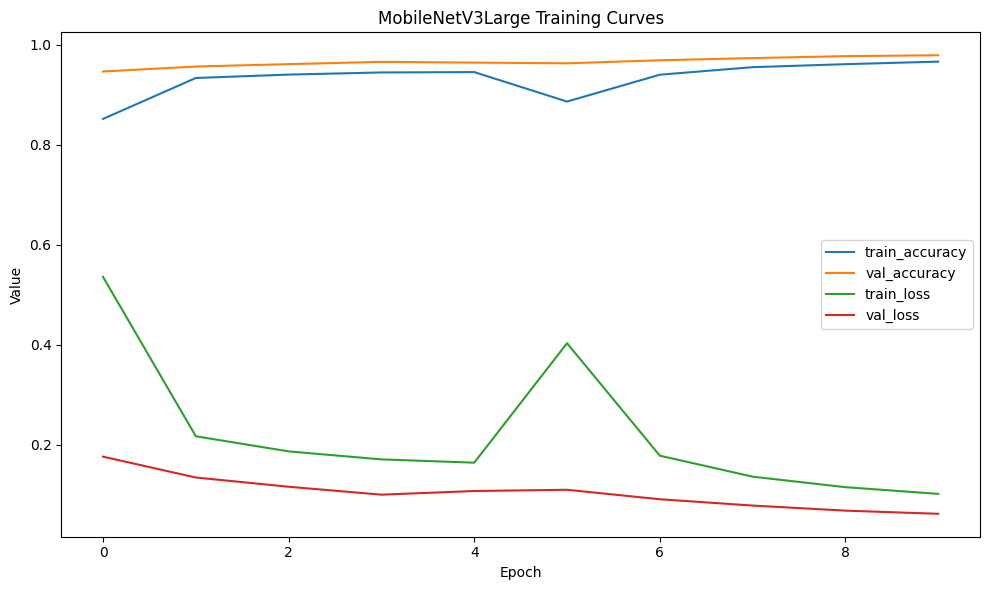

Saved history: /kaggle/working/outputs/training_logs/mobilenetv3large_history.csv
Saved curve: /kaggle/working/outputs/metrics/mobilenetv3large_training_curves.png


In [23]:
head_df = pd.DataFrame(history_head.history)
head_df["stage"] = "head_training"

fine_df = pd.DataFrame(history_fine.history)
fine_df["stage"] = "fine_tuning"

history_df = pd.concat([head_df, fine_df], ignore_index=True)

combined_history_path = LOGS_DIR / "mobilenetv3large_history.csv"
history_df.to_csv(combined_history_path, index=False)

plt.figure(figsize=(10, 6))
plt.plot(history_df["accuracy"], label="train_accuracy")
plt.plot(history_df["val_accuracy"], label="val_accuracy")
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Value")
plt.title("MobileNetV3Large Training Curves")
plt.legend()
plt.tight_layout()

curve_path = METRICS_DIR / "mobilenetv3large_training_curves.png"
plt.savefig(curve_path, dpi=200)
plt.show()

print("Saved history:", combined_history_path)
print("Saved curve:", curve_path)

In [24]:
y_true = []
y_pred = []
y_prob = []

for images, labels in valid_ds:
    probs = best_model.predict(images, verbose=0)
    preds = np.argmax(probs, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(preds)
    y_prob.extend(probs)

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

print("y_true shape:", y_true.shape)
print("y_pred shape:", y_pred.shape)
print("y_prob shape:", y_prob.shape)

y_true shape: (17572,)
y_pred shape: (17572,)
y_prob shape: (17572, 38)


In [25]:
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True,
    zero_division=0,
)

report_df = pd.DataFrame(report_dict).transpose()

classification_report_path = METRICS_DIR / "mobilenetv3large_classification_report.csv"
report_df.to_csv(classification_report_path)

report_df.head()

,precision,recall,f1-score,support
Apple___Apple_scab,0.986111,0.986111,0.986111,504.0
Apple___Black_rot,0.988072,1.000000,0.994000,497.0
Apple___Cedar_apple_rust,1.000000,1.000000,1.000000,440.0
Apple___healthy,0.992063,0.996016,0.994036,502.0
Blueberry___healthy,0.997802,1.000000,0.998900,454.0


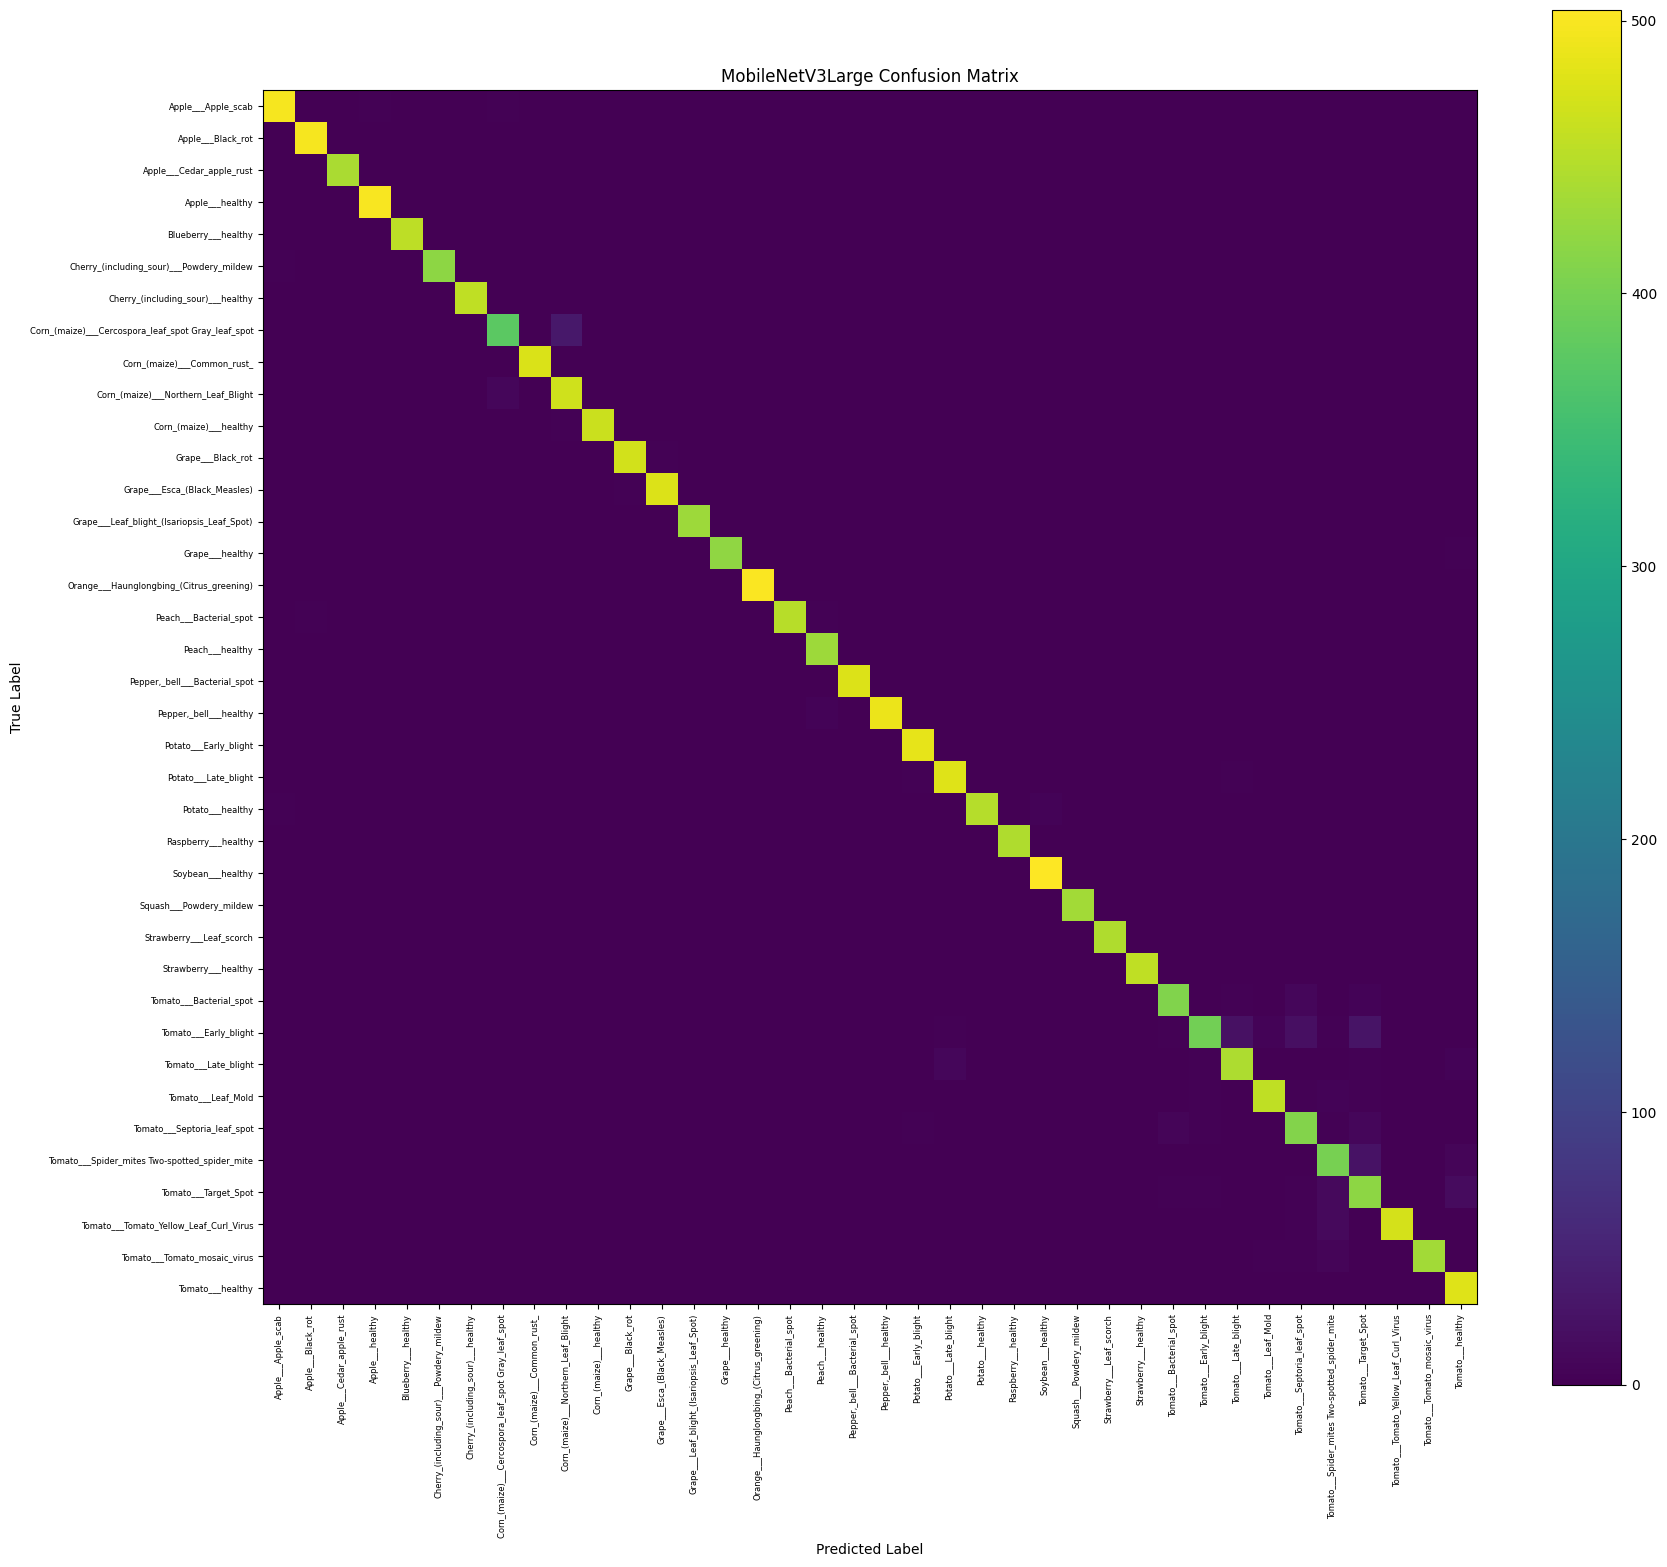

Saved: /kaggle/working/outputs/metrics/mobilenetv3large_confusion_matrix.png


In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(18, 16))
plt.imshow(cm, interpolation="nearest")
plt.title("MobileNetV3Large Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names, rotation=90, fontsize=6)
plt.yticks(tick_marks, class_names, fontsize=6)

plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()

confusion_matrix_path = METRICS_DIR / "mobilenetv3large_confusion_matrix.png"
plt.savefig(confusion_matrix_path, dpi=250)
plt.show()

print("Saved:", confusion_matrix_path)

In [27]:
wrong_indices = np.where(y_true != y_pred)[0]

error_summary = []

for idx in wrong_indices[:300]:
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    confidence = float(np.max(y_prob[idx]))

    error_summary.append({
        "true_class": true_label,
        "predicted_class": pred_label,
        "confidence": confidence,
    })

error_df = pd.DataFrame(error_summary)

error_path = ERROR_DIR / "mobilenetv3large_wrong_predictions_summary.csv"
error_df.to_csv(error_path, index=False)

error_df.head(20)

,true_class,predicted_class,confidence
0,Apple___Apple_scab,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.938372
1,Apple___Apple_scab,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,0.775858
2,Apple___Apple_scab,Apple___healthy,0.624949
3,Apple___Apple_scab,Apple___Black_rot,0.605014
4,Apple___Apple_scab,Tomato___healthy,0.478703
5,Apple___Apple_scab,Apple___healthy,0.578987
6,Apple___Apple_scab,Apple___healthy,0.906632
7,Apple___healthy,Apple___Apple_scab,0.427892
8,Apple___healthy,Tomato___healthy,0.947230
9,Cherry_(including_sour)___Powdery_mildew,Apple___Apple_scab,0.395146


In [28]:
model_metadata = {
    "project": "CropGuard AI",
    "model_name": "mobilenetv3large_transfer",
    "dataset": "Kaggle New Plant Diseases Dataset",
    "num_classes": int(num_classes),
    "image_size": list(IMAGE_SIZE),
    "batch_size": int(BATCH_SIZE),
    "head_epochs": int(HEAD_EPOCHS),
    "fine_tune_epochs": int(FINE_TUNE_EPOCHS),
    "total_epochs": int(TOTAL_EPOCHS),
    "train_images": int(train_total),
    "valid_images": int(valid_total),
    "metrics": {
        "accuracy": float(results["accuracy"]),
        "loss": float(results["loss"]),
        "top_3_accuracy": float(results["top_3_accuracy"]),
    },
    "notes": [
        "MobileNetV3Large is trained as a lightweight deployment-friendly comparison model.",
        "The pretrained base was frozen first, then partially fine-tuned.",
        "This model is compared against Custom CNN and EfficientNetV2B0.",
    ],
}

metadata_path = MODELS_DIR / "mobilenetv3large_model_metadata.json"

with open(metadata_path, "w", encoding="utf-8") as f:
    json.dump(model_metadata, f, indent=4)

print("Saved:", metadata_path)

Saved: /kaggle/working/models/mobilenetv3large_model_metadata.json


In [ ]:
for path in WORKING_DIR.rglob("*"):
    if path.is_file():
        print(path)

In [29]:
zip_path = WORKING_DIR / "cropguard_mobilenetv3large_outputs.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zipf:
    for folder in [MODELS_DIR, OUTPUTS_DIR]:
        for file_path in folder.rglob("*"):
            if file_path.is_file():
                zipf.write(file_path, file_path.relative_to(WORKING_DIR))

print("Created ZIP:", zip_path)

Created ZIP: /kaggle/working/cropguard_mobilenetv3large_outputs.zip


In [30]:
from IPython.display import FileLink

FileLink("/kaggle/working/cropguard_mobilenetv3large_outputs.zip")

/kaggle/working/cropguard_mobilenetv3large_outputs.zip

In [31]:
print("MOBILENETV3LARGE TRAINING COMPLETE")
print("----------------------------------")
print("Accuracy:", results["accuracy"])
print("Loss:", results["loss"])
print("Top-3 Accuracy:", results["top_3_accuracy"])
print("Model saved at:", model_path)
print("ZIP saved at:", zip_path)

MOBILENETV3LARGE TRAINING COMPLETE
----------------------------------
Accuracy: 0.9792283177375793
Loss: 0.061757247895002365
Top-3 Accuracy: 0.9986342191696167
Model saved at: /kaggle/working/models/mobilenetv3large_best.keras
ZIP saved at: /kaggle/working/cropguard_mobilenetv3large_outputs.zip
